In [72]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [73]:
df = pd.read_csv('../Data/d_output.csv')

In [74]:
print(len(df))

500


In [75]:
df.head()

,Number,Sex,%Red Pixel,%Green pixel,%Blue pixel,Hb,Anaemic
0,1,M,43.170845,30.945626,25.921971,6.252659,Yes
1,2,F,43.163481,30.306974,26.759843,8.578865,Yes
2,3,F,46.269997,27.315656,26.028556,9.640936,Yes
3,4,F,45.054787,30.469816,24.460797,4.794217,Yes
4,5,M,45.061884,31.218572,24.071714,8.865329,Yes


In [76]:
df.columns

Index(['Number', 'Sex', '%Red Pixel', '%Green pixel', '%Blue pixel', 'Hb',
       'Anaemic'],
      dtype='object')

In [77]:
def brightness_calc(df, red, green, blue):
    
    brightness = df[red]*0.2126 + df[green]*0.7152 + df[blue]*0.0722
    
    return brightness

In [78]:
df['Brightness'] = brightness_calc(df, '%Red Pixel', '%Green pixel', '%Blue pixel') 

In [79]:
df['Sex'] = df['Sex'].str.strip()

In [95]:
df['Anaemic'] = df['Anaemic'].map({'Yes': 1, 'No': 0})

In [96]:
df.head()

,Number,Sex,%Red Pixel,%Green pixel,%Blue pixel,Hb,Anaemic,Brightness
0,310,F,42.522123,30.780178,26.796185,8.751469,1,32.988871
1,120,F,46.883092,28.310935,24.339006,8.467931,1,31.972602
2,168,M,43.575386,30.765669,25.707342,9.900000,1,33.123804
3,295,M,45.679516,30.081195,24.254389,9.149744,1,32.976703
4,393,M,46.872953,28.224643,24.883969,14.087730,0,31.948077


In [97]:
cat_cols = ['Sex']
cont_cols = ['Hb', 'Brightness']
y_col = ['Anaemic']

In [98]:
for cat in cat_cols:
    df[cat] = df[cat].astype('category')

In [99]:
df = df.sample(frac=1).reset_index(drop=True)

In [100]:
df.head()

,Number,Sex,%Red Pixel,%Green pixel,%Blue pixel,Hb,Anaemic,Brightness
0,116,M,43.421695,30.699521,25.864472,9.843736,1,33.055165
1,199,M,41.264864,32.416702,26.469342,9.848717,1,33.868422
2,446,M,48.725465,26.379251,24.914068,15.597316,0,31.024270
3,89,F,50.448388,25.023080,24.332812,11.476212,0,30.378663
4,459,F,45.441014,29.535560,25.041398,12.031311,0,32.592581


In [101]:
cat_szs = [len(df[col].cat.categories) for col in cat_cols]
emb_szs = [(size,min(50, (size+1)//2)) for size in cat_szs]
emb_szs

[(2, 1)]

In [102]:
sex = df['Sex'].cat.codes.values
cats = np.stack([sex], axis=1)

In [103]:
cats[:5]

array([[1],
       [1],
       [1],
       [0],
       [0]], dtype=int8)

In [104]:
cats = torch.tensor(cats, dtype=torch.int64)

In [105]:
conts = np.stack([df[col].values for col in cont_cols],axis=1)
conts[:5]

array([[ 9.84373571, 33.05516467],
       [ 9.84871692, 33.86842181],
       [15.59731592, 31.02426988],
       [11.47621158, 30.37866317],
       [12.03131105, 32.59258114]])

In [106]:
conts = torch.tensor(conts, dtype=torch.float)

In [107]:
y = torch.tensor(df[y_col].values).flatten()

In [108]:
b = 426
t = 74

cat_train = cats[:b-t]
cat_test = cats[b-t:b]
con_train = conts[:b-t]
con_test = conts[b-t:b]
y_train = y[:b-t]
y_test = y[b-t:b]

In [109]:
class TabularModel(nn.Module):

    def __init__(self, emb_szs, n_cont, out_sz, layers, p=0.5):
        # Call the parent __init__
        super().__init__()
        
        # Set up the embedding, dropout, and batch normalization layer attributes
        self.embeds = nn.ModuleList([nn.Embedding(ni, nf) for ni,nf in emb_szs])
        self.emb_drop = nn.Dropout(p)
        self.bn_cont = nn.BatchNorm1d(n_cont)
        
        # Assign a variable to hold a list of layers
        layerlist = []
        
        # Assign a variable to store the number of embedding and continuous layers
        n_emb = sum((nf for ni,nf in emb_szs))
        n_in = n_emb + n_cont
        
        # Iterate through the passed-in "layers" parameter (ie, [200,100]) to build a list of layers
        for i in layers:
            layerlist.append(nn.Linear(n_in,i)) 
            layerlist.append(nn.ReLU(inplace=True))
            layerlist.append(nn.BatchNorm1d(i))
            layerlist.append(nn.Dropout(p))
            n_in = i
        layerlist.append(nn.Linear(layers[-1],out_sz))
        
        # Convert the list of layers into an attribute
        self.layers = nn.Sequential(*layerlist)
    
    def forward(self, x_cat, x_cont):
        # Extract embedding values from the incoming categorical data
        embeddings = []
        for i,e in enumerate(self.embeds):
            embeddings.append(e(x_cat[:,i]))
        x = torch.cat(embeddings, 1)
        # Perform an initial dropout on the embeddings
        x = self.emb_drop(x)
        
        # Normalize the incoming continuous data
        x_cont = self.bn_cont(x_cont)
        x = torch.cat([x, x_cont], 1)
        
        # Set up model layers
        x = self.layers(x)
        return x

In [110]:
model = TabularModel(emb_szs,conts.shape[1], 2, [50], p=0.4)
model

TabularModel(
  (embeds): ModuleList(
    (0): Embedding(2, 1)
  )
  (emb_drop): Dropout(p=0.4, inplace=False)
  (bn_cont): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): Sequential(
    (0): Linear(in_features=3, out_features=50, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=50, out_features=2, bias=True)
  )
)

In [111]:
criterion = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [112]:
import time
start_time = time.time()

epochs = 300
losses = []

for i in range(epochs):
    i+=1
    y_pred = model(cat_train, con_train)
    loss = criterion(y_pred, y_train)
    losses.append(loss)
    
    # a neat trick to save screen space:
    if i%25 == 1:
        print(f'epoch: {i:3}  loss: {loss.item():10.8f}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f'epoch: {i:3}  loss: {loss.item():10.8f}') # print the last line
print(f'\nDuration: {time.time() - start_time:.0f} seconds') # print the time elapsed

epoch:   1  loss: 0.60095775
epoch:  26  loss: 0.30116570
epoch:  51  loss: 0.19252548
epoch:  76  loss: 0.14138466
epoch: 101  loss: 0.11287138
epoch: 126  loss: 0.09969182
epoch: 151  loss: 0.07201403
epoch: 176  loss: 0.06835690
epoch: 201  loss: 0.06304458
epoch: 226  loss: 0.05301367
epoch: 251  loss: 0.04867804
epoch: 276  loss: 0.04469415
epoch: 300  loss: 0.04194173

Duration: 1 seconds


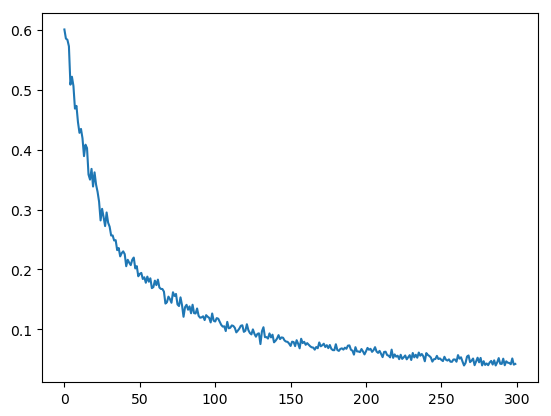

In [113]:
plt.plot(range(epochs),losses)


In [114]:
with torch.no_grad():
    
    y_val = model(cat_test, con_test)
    
    loss = criterion(y_val, y_test)


# RUN THIS CODE TO COMPARE RESULTS
print(f'CE Loss: {loss:.8f}')

CE Loss: 0.06850674


In [117]:
rows = len(y_test)
correct = 0

# print(f'{"MODEL OUTPUT":26} ARGMAX  Y_TEST')

for i in range(rows):
    # print(f'{str(y_val[i]):26} {y_val[i].argmax().item():^7}{y_test[i]:^7}')

    if y_val[i].argmax().item() == y_test[i]:
        correct += 1

print(f'\n{correct} out of {rows} = {100*correct/rows:.2f}% correct')






73 out of 74 = 98.65% correct


In [118]:
torch.save(model.state_dict(), 'AnaemiaModel.pt')